In [ ]:
'''
ML Pipeline for Gridded Precip Project (XGBoost) - both IDW and kriging input options

Overview and Motivation
The goal of this workflow is to integrate heterogeneous observational, satellite, and climatological datasets into a unified, physically informed ML framework 
for predicting precipitation phase (rain, snow, or mixed). Because direct precipitation-phase observations are sparse and unevenly distributed in space and time, 
we adopt a weakly supervised labeling approach using an interpolated MRoS proxy, combined with spatially blocked ML training to handle prediction across complex terrain.

1. Gridded surface preprocessing
All predictor layers are aligned to a common coordinate reference system, grid resolution, and timestamp index.
Output: Stacked gridded predictor datasets (NetCDF), one layer per variable per hour.

2. Precip phase labeling via MRoS proxy
The interpolated MRoS proxy surface is converted into discrete phase classes:
The MRoS proxy is used exclusively for labeling and is not included as a predictor to avoid target leakage.
Output: A space-time mask identifying gridcell-hours with usable phase labels.

3. Feature table construction: 
Transform gridded data back into tabular format required for ML processing
Output: a tabular dataset (e.g., parquet) suitable for ML training

4. Spatial blocking to split data
Motivation: spatial blocking accounts for spatial autocorrelation and avoids overestimated performance that arise from random splits.

5. ML model training
XGBoost multiclass classifier: 
Target: predict rain, mix, or snow probabilities
Outputs class probabilities (& uncertainty)
Model hyperparameter tuning on validation set
tree depth, learning rate, subsampling, min_child_weight, etc.
stopping criteria via early stopping on validation loss

6. Model evaluation and performance
Model performance is evaluated on a fully held-out test set.
Accuracy / Macro F1 (for balanced class performance)
RMSE or MAE if numeric encoding used for rain/mix/snow
Brier Score (probabilistic accuracy)
Bias / Confusion matrices
Stratify results:
By elevation band (e.g., <1500 m, 1500-2500 m, >2500 m)
By station density or IMEGR PLP intensity

7. Model interpretation
Goal: Understand what drives predictions
Compute SHAP values for each feature → shows its contribution to each class probability.

'''


'\nML Pipeline for Gridded Precip Project (XGBoost)\n\nOverview and Motivation\nThe goal of this workflow is to integrate heterogeneous observational, satellite, and climatological datasets into a unified, physically informed ML framework \nfor predicting precipitation phase (rain, snow, or mixed). Because direct precipitation-phase observations are sparse and unevenly distributed in space and time, \nwe adopt a weakly supervised labeling approach using an interpolated MRoS proxy, combined with spatially blocked ML training to handle prediction across complex terrain.\n\n1. Gridded surface preprocessing\nAll predictor layers are aligned to a common coordinate reference system, grid resolution, and timestamp index.\nOutput: Stacked gridded predictor datasets (NetCDF), one layer per variable per hour.\n\n2. Precip phase labeling via MRoS proxy\nThe interpolated MRoS proxy surface is converted into discrete phase classes:\nThe MRoS proxy is used exclusively for labeling and is not include

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt

In [2]:
BASE_DIR = Path().resolve().parent  # current working dir
print("BASE_DIR:", BASE_DIR)

ML_DIR = BASE_DIR / "ML_pipeline"
print("ML_DIR:", ML_DIR)

DATA_DIR = Path("C:/Users/EmmaGolub/Desktop/MRoS_local/local_data") # change to USER's local folder where large data files are stored
print("DATA_DIR:", DATA_DIR)

PATHS = {
    "IDW": DATA_DIR / "IDW/hourly_predictors_1km_IDW_full.nc",
    "kriging": DATA_DIR / "kriging/hourly_predictors_1km_kriging_v1_final.nc",
    "imerg": DATA_DIR / "resampled_grids/imerg_hourly_1km.nc",
    "prism": DATA_DIR / "resampled_grids/prism_hourly_1km.nc",
}

SETUP_DIR = DATA_DIR / "compiled_input_predictors"
SETUP_DIR.mkdir(exist_ok=True)
print("SETUP_DIR:", SETUP_DIR)

interp_type = "kriging" # "IDW" or "kriging"

if interp_type == "IDW":
    interp_type_folder = "withIDW"
elif interp_type == "kriging":
    interp_type_folder = "withKriging"

MODEL_OUT_DIR = ML_DIR / "model_artifacts" / interp_type_folder
MODEL_OUT_DIR.mkdir(exist_ok=True)
print("MODEL_OUT_DIR:", MODEL_OUT_DIR)

GRAPHICS_DIR = MODEL_OUT_DIR / "graphics"
GRAPHICS_DIR.mkdir(exist_ok=True)
print("GRAPHICS_DIR:", GRAPHICS_DIR)


BASE_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype
ML_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\ML_pipeline
DATA_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\local_data
SETUP_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\local_data\compiled_input_predictors
MODEL_OUT_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\ML_pipeline\model_artifacts\withKriging
GRAPHICS_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\ML_pipeline\model_artifacts\withKriging\graphics


## Step  1: Input Dataset QAQC Checks and Preprocessing

In [3]:
## Checking time synchroniziation -------------------------------------------------

ds_IDW = xr.open_dataset(PATHS["IDW"])
ds_kriging = xr.open_dataset(PATHS["kriging"])
ds_imerg = xr.open_dataset(PATHS["imerg"])
ds_prism = xr.open_dataset(PATHS["prism"])

for name, ds in {
    "IDW": ds_IDW,
    "kriging": ds_kriging,
    "IMERG": ds_imerg,
    "PRISM": ds_prism,
}.items():
    print(f"\n{name}")
    print(ds)

def summarize_time(ds, name):
    t = ds["time"]
    print(f"\n{name} time summary:")
    print("  start:", pd.to_datetime(t.values[0]))
    print("  end:  ", pd.to_datetime(t.values[-1]))
    print("  n:", t.size)
    print("  freq guess:", pd.infer_freq(pd.to_datetime(t.values[:10])))

summarize_time(ds_IDW, "IDW")
summarize_time(ds_kriging, "kriging")
summarize_time(ds_imerg, "IMERG")
summarize_time(ds_prism, "PRISM")


IDW
<xarray.Dataset> Size: 5GB
Dimensions:         (time: 5832, y: 251, x: 142)
Coordinates:
  * y               (y) float64 2kB 4.426e+06 4.425e+06 ... 4.177e+06 4.176e+06
  * x               (x) float64 1kB 1.626e+05 1.636e+05 ... 3.026e+05 3.036e+05
  * time            (time) datetime64[ns] 47kB 2024-10-01 ... 2025-05-31T23:0...
Data variables:
    temp_air        (time, y, x) float32 831MB ...
    temp_dew        (time, y, x) float32 831MB ...
    temp_wet        (time, y, x) float32 831MB ...
    rh              (time, y, x) float32 831MB ...
    mros_plp_proxy  (time, y, x) float32 831MB ...
    plp             (time, y, x) float32 831MB ...
    elev            (y, x) float32 143kB ...
    spatial_ref     int64 8B ...
Attributes:
    title:             Hourly predictor stacks on 1-km grid
    lapse_degC_per_m:  -0.005
    idw_power:         2.0
    k_nearest:         8
    GeoTransform:      162130.9182594687 1000.0 0.0 4426426.168783374 0.0 -10...

kriging
<xarray.Dataset> Size

In [4]:
# Assign interpolation type toggle

if interp_type == "IDW":
    ds_interp = ds_IDW
elif interp_type == "kriging":
    ds_interp = ds_kriging
else:
    raise ValueError(f"Unknown interp_type: {interp_type}")

In [5]:
common_times = np.intersect1d(
    ds_interp.time.values,
    ds_imerg.time.values
)
common_times = np.intersect1d(
    common_times,
    ds_prism.time.values
)

print(f"Common timesteps across IMERG, PRISM, and {interp_type}:",
      len(common_times))

Common timesteps across IMERG, PRISM, and kriging: 5160


In [6]:
ds_interp = ds_interp.sel(time=common_times)
ds_imerg = ds_imerg.sel(time=common_times)
ds_prism = ds_prism.sel(time=common_times)

In [7]:
## Checking grid synchroniziation -------------------------------------------------

def summarize_grid(ds, name):
    print(f"\n{name} grid:")
    for dim in ["x", "y"]:
        if dim in ds.dims:
            vals = ds[dim].values
            print(f"  {dim}: n={len(vals)}, "
                  f"min={vals.min():.2f}, max={vals.max():.2f}, "
                  f"dx≈{np.mean(np.diff(vals)):.2f}")

summarize_grid(ds_interp, f"{interp_type}")
summarize_grid(ds_imerg, "IMERG")
summarize_grid(ds_prism, "PRISM")



kriging grid:
  x: n=142, min=162630.92, max=303630.92, dx≈1000.00
  y: n=251, min=4175926.17, max=4425926.17, dx≈-1000.00

IMERG grid:
  x: n=142, min=162630.92, max=303630.92, dx≈1000.00
  y: n=251, min=4175926.17, max=4425926.17, dx≈-1000.00

PRISM grid:
  x: n=142, min=162630.92, max=303630.92, dx≈1000.00
  y: n=251, min=4175926.17, max=4425926.17, dx≈-1000.00


In [11]:
## Checking general stats -------------------------------------------------

def quick_stats(ds, var):
    v = ds[var]
    return {
        "min": float(v.min()),
        "max": float(v.max()),
        "nan_frac": float(v.isnull().mean())
    }

for var in ds_prism.data_vars:
    print("PRISM", var, quick_stats(ds_prism, var))


PRISM prism_tair {'min': -26.73922626164204, 'max': 34.437614700831105, 'nan_frac': 0.0}
PRISM prism_tmean {'min': -16.262734494423775, 'max': 25.713881844107153, 'nan_frac': 0.0}
PRISM prism_tdmean {'min': -28.220525136197175, 'max': 15.807606480060583, 'nan_frac': 0.0}
PRISM prism_ppt_daily {'min': 0.0, 'max': 179.0049390438019, 'nan_frac': 0.0}
PRISM spatial_ref {'min': 0.0, 'max': 0.0, 'nan_frac': 0.0}


In [12]:
## Checking internal time counts/distribution -------------------------------------------------


def time_qc(ds, name):
    t = pd.to_datetime(ds.time.values)
    print(f"\n{name} time QC:")
    print("  monotonic:", (np.diff(t.values) > np.timedelta64(0, "s")).all())
    print("  unique:", len(t) == len(np.unique(t)))
    # Check that all are on the hour
    print("  all on hour:", np.all(t.minute == 0) and np.all(t.second == 0))

    # Check per-day counts
    per_day_counts = pd.Series(1, index=t).resample("D").sum()
    print("  per-day count summary:")
    print(per_day_counts.describe())

time_qc(ds_interp, f"{interp_type}")
time_qc(ds_imerg, "IMERG")
time_qc(ds_prism, "PRISM")



kriging time QC:
  monotonic: True
  unique: True
  all on hour: True
  per-day count summary:
count    232.000000
mean      22.241379
std        6.267653
min        0.000000
25%       24.000000
50%       24.000000
75%       24.000000
max       24.000000
dtype: float64

IMERG time QC:
  monotonic: True
  unique: True
  all on hour: True
  per-day count summary:
count    232.000000
mean      22.241379
std        6.267653
min        0.000000
25%       24.000000
50%       24.000000
75%       24.000000
max       24.000000
dtype: float64

PRISM time QC:
  monotonic: True
  unique: True
  all on hour: True
  per-day count summary:
count    232.000000
mean      22.241379
std        6.267653
min        0.000000
25%       24.000000
50%       24.000000
75%       24.000000
max       24.000000
dtype: float64


In [ ]:
## Checking somre more stats -------------------------------------------------

def var_stats(ds, vars_, name):
    print(f"\n{name} value stats:")
    for v in vars_:
        da = ds[v]
        print(
            f"  {v}: "
            f"min={float(da.min()):.2f}, "
            f"max={float(da.max()):.2f}, "
            f"nan_frac={float(da.isnull().mean()):.4f}"
        )

var_stats(
    ds_interp,
    ["temp_air", "temp_dew", "temp_wet", "rh", "mros_plp_proxy", "plp"],
    interp_type
)
# TODO: check any non-zero nan_frac here

var_stats(ds_imerg, ["imerg_plp"], "IMERG")

var_stats(
    ds_prism,
    ["prism_tair", "prism_tmean", "prism_tdmean", "prism_ppt_daily"],
    "PRISM"
)



kriging value stats:
  temp_air: min=-21.04, max=36.66, nan_frac=0.0000
  temp_dew: min=-30.77, max=18.58, nan_frac=0.0000
  temp_wet: min=-21.96, max=25.15, nan_frac=0.0000
  rh: min=-27.73, max=135.93, nan_frac=0.0000
  mros_plp_proxy: min=0.00, max=100.00, nan_frac=0.8667
  plp: min=-6.90, max=115.67, nan_frac=0.0000

IMERG value stats:
  imerg_plp: min=0.00, max=100.00, nan_frac=0.0000

PRISM value stats:
  prism_tair: min=-26.74, max=34.44, nan_frac=0.0000
  prism_tmean: min=-16.26, max=25.71, nan_frac=0.0000
  prism_tdmean: min=-28.22, max=15.81, nan_frac=0.0000
  prism_ppt_daily: min=0.00, max=179.00, nan_frac=0.0000


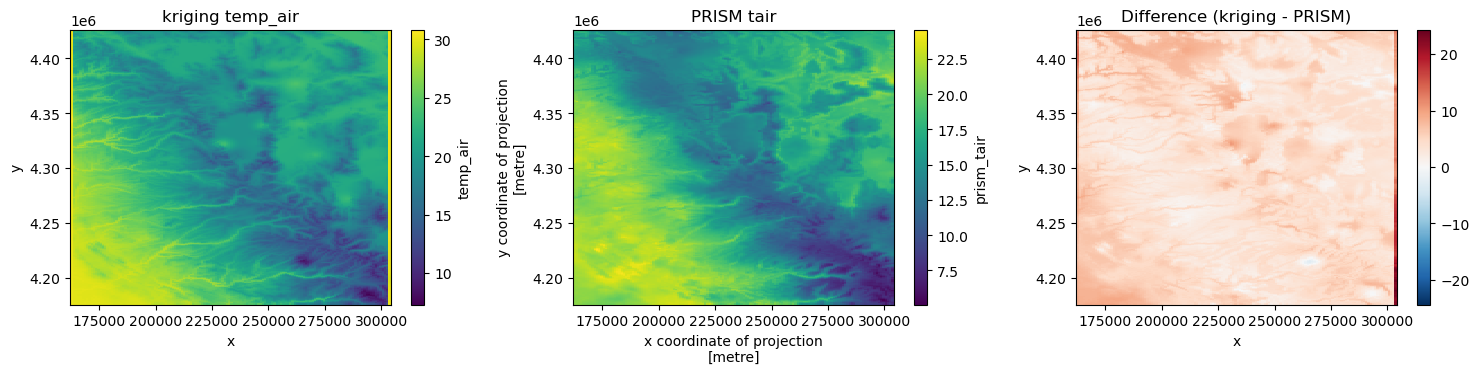

In [ ]:
## Visualize timestep -------------------------------------------------

# IDW / kriging station t_air vs PRISM t_air
t0 = ds_imerg.time.values[0]

interp_t = ds_interp["temp_air"].sel(time=t0)
prism_t = ds_prism["prism_tair"].sel(time=t0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
interp_t.plot(ax=axes[0])
axes[0].set_title(f"{interp_type} temp_air")

prism_t.plot(ax=axes[1])
axes[1].set_title("PRISM tair")

(interp_t - prism_t).plot(ax=axes[2])
axes[2].set_title(f"Difference ({interp_type} - PRISM)")

plt.tight_layout()

plt.savefig(GRAPHICS_DIR / f"timestep_compare_temp_air_{interp_type}.png", dpi=200, bbox_inches="tight")


In [8]:
# Finally intersect times and commit to common period

common_times = np.intersect1d(
    ds_interp.time.values,
    ds_imerg.time.values
)
common_times = np.intersect1d(common_times, ds_prism.time.values)

ds_interp   = ds_interp.sel(time=common_times)
ds_imerg = ds_imerg.sel(time=common_times)
ds_prism = ds_prism.sel(time=common_times)

assert ds_interp.time.identical(ds_imerg.time)
assert ds_interp.time.identical(ds_prism.time)


In [ ]:
# Build one xarray dataset containing only the predictors

predictors = xr.Dataset(
    {
        # IDW / kriging (ds_interp)
        "temp_air": ds_interp["temp_air"],
        "temp_dew": ds_interp["temp_dew"],
        "temp_wet": ds_interp["temp_wet"],
        "rh": ds_interp["rh"],

        # IMERG
        "imerg_plp": ds_imerg["imerg_plp"],

        # PRISM
        "prism_tair": ds_prism["prism_tair"],
        "prism_tmean": ds_prism["prism_tmean"],
        "prism_tdmean": ds_prism["prism_tdmean"],
        "prism_ppt_daily": ds_prism["prism_ppt_daily"],

        # Static
        "elev": ds_interp["elev"],
    },
    coords={
        "time": ds_interp.time,
        "x": ds_interp.x,
        "y": ds_interp.y,
    }
)
print(predictors)

if interp_type == "IDW":
    out_nc = SETUP_DIR / "predictors_hourly_1km_withIDW.nc"
elif interp_type == "kriging":
    out_nc = SETUP_DIR / "predictors_hourly_1km_withKriging.nc"
else:
    raise ValueError(f"Unknown interp_type: {interp_type}")

predictors.to_netcdf(
    out_nc,
    encoding={v: {"zlib": True, "complevel": 4} for v in predictors.data_vars}
)

print("Saved input predictor stack")


<xarray.Dataset> Size: 10GB
Dimensions:          (y: 251, x: 142, time: 5160)
Coordinates:
  * y                (y) float64 2kB 4.426e+06 4.425e+06 ... 4.177e+06 4.176e+06
  * x                (x) float64 1kB 1.626e+05 1.636e+05 ... 3.026e+05 3.036e+05
  * time             (time) datetime64[ns] 41kB 2024-10-11 ... 2025-05-30T23:...
Data variables:
    temp_air         (time, y, x) float32 736MB ...
    temp_dew         (time, y, x) float32 736MB ...
    temp_wet         (time, y, x) float32 736MB ...
    rh               (time, y, x) float32 736MB ...
    imerg_plp        (time, y, x) float64 1GB ...
    prism_tair       (time, y, x) float64 1GB ...
    prism_tmean      (time, y, x) float64 1GB ...
    prism_tdmean     (time, y, x) float64 1GB ...
    prism_ppt_daily  (time, y, x) float64 1GB ...
    elev             (y, x) float32 143kB ...


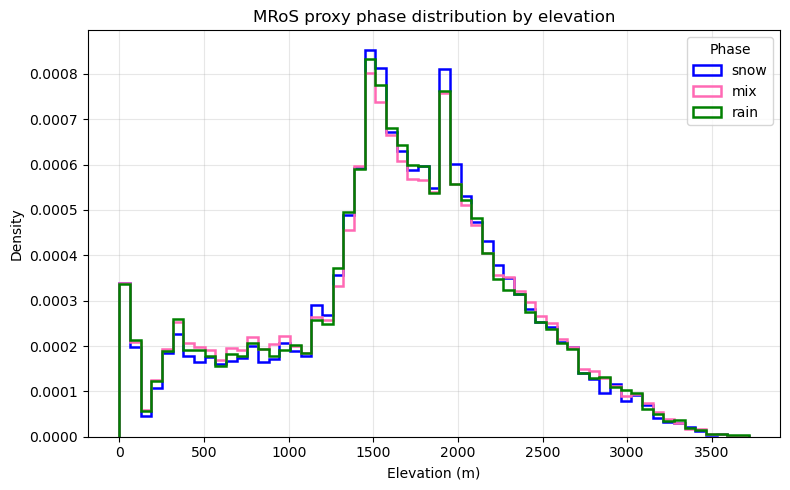

In [20]:
# -------------------------------------------------------------------
# Visualize MRoS proxy phase distribution and predictors vs elevation
# -------------------------------------------------------------------
import matplotlib.pyplot as plt


# Find common time range across all three datasets
common_time = np.intersect1d(
    np.intersect1d(ds_IDW["time"].values, ds_imerg["time"].values),
    ds_prism["time"].values,
)

eda_ds = xr.Dataset(
    {
        "temp_air":      ds_IDW["temp_air"].sel(time=common_time),
        "temp_dew":      ds_IDW["temp_dew"].sel(time=common_time),
        "temp_wet":      ds_IDW["temp_wet"].sel(time=common_time),
        "rh":            ds_IDW["rh"].sel(time=common_time),
        "mros_plp_proxy": ds_IDW["mros_plp_proxy"].sel(time=common_time),
        "imerg_plp":     ds_imerg["imerg_plp"].sel(time=common_time),
        "prism_tair":    ds_prism["prism_tair"].sel(time=common_time),
        "prism_tmean":   ds_prism["prism_tmean"].sel(time=common_time),
        "prism_tdmean":  ds_prism["prism_tdmean"].sel(time=common_time),
        "elev":          ds_IDW["elev"],  # broadcast over time automatically
    },
    coords={
        "time": common_time,
        "y": ds_IDW["y"],
        "x": ds_IDW["x"],
    },
)

# 2. Stack to a 1D "sample" dimension and go to pandas for plotting
stacked = eda_ds.stack(sample=("time", "y", "x"))

# Keep only rows where the MRoS proxy exists 
df_visualize = stacked.to_dataframe().dropna(subset=["mros_plp_proxy"])

# Optional down-sampling for speed (adjust n if you want more/less)
max_samples = 200_000
if len(df_visualize) > max_samples:
    df_visualize = df_visualize.sample(n=max_samples, random_state=42)

# 3. Define phase from MRoS proxy:
#    0   -> snow
#    100 -> rain
#    else -> mix
phase_arr = np.where(
    df_visualize["mros_plp_proxy"] == 0, 0,
    np.where(df_visualize["mros_plp_proxy"] == 100, 2, 1)
)
df_visualize["phase"] = phase_arr

phase_name_map = {0: "snow", 1: "mix", 2: "rain"}
df_visualize["phase_name"] = df_visualize["phase"].map(phase_name_map)

# -------------------------------------------------------------------
# A. Phase distribution by elevation (hist overlays)
# -------------------------------------------------------------------
plt.figure(figsize=(8, 5))
bins = np.linspace(df_visualize["elev"].min(), df_visualize["elev"].max(), 60)

colors = {"snow": "blue", "mix": "#ff69b4", "rain": "green"}

for ph, name in phase_name_map.items():
    elev_vals = df_visualize.loc[df_visualize["phase"] == ph, "elev"].values
    if len(elev_vals) == 0:
        continue
    plt.hist(
        elev_vals,
        bins=bins,
        histtype="step",
        density=True,
        label=name,
        color=colors[name],
        linewidth=1.8,
    )

plt.xlabel("Elevation (m)")
plt.ylabel("Density")
plt.title("MRoS proxy phase distribution by elevation")
plt.legend(title="Phase")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

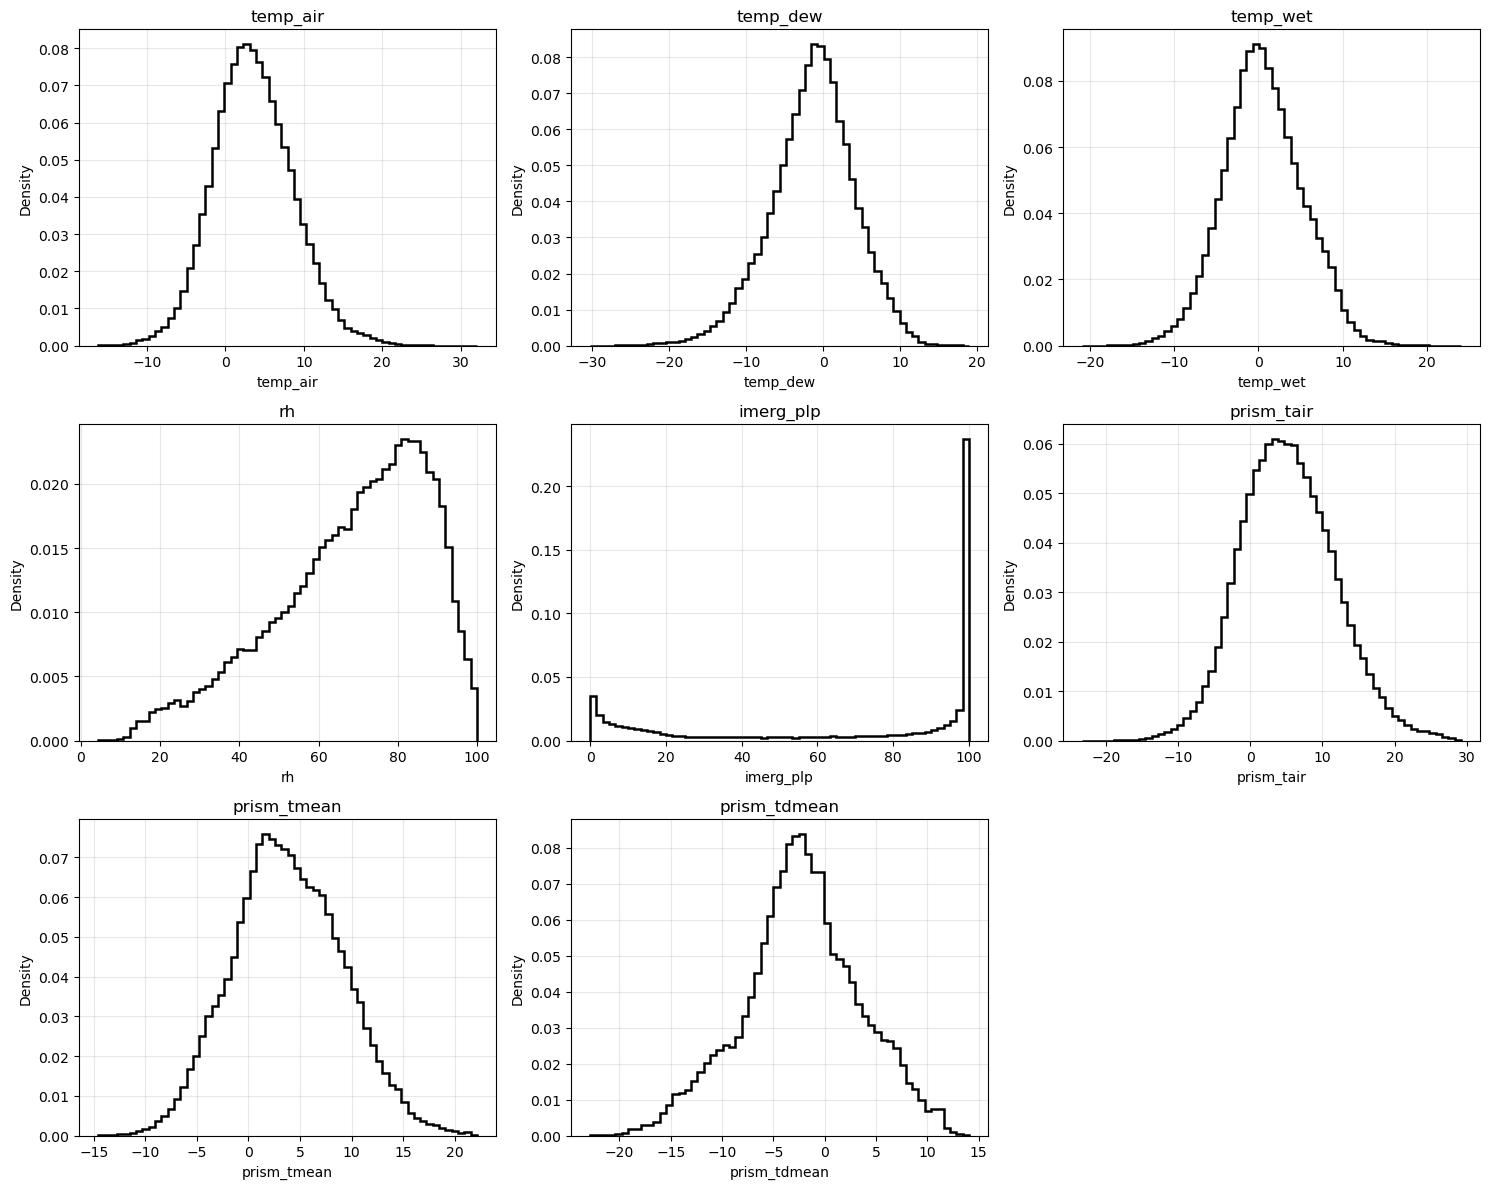

In [15]:
# -------------------------------------------------------------------
# B.2 Predictor marginal distributions (1D density histograms)
# -------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

predictors = [
    "temp_air",
    "temp_dew",
    "temp_wet",
    "rh",
    "imerg_plp",
    "prism_tair",
    "prism_tmean",
    "prism_tdmean",
]

n_vars = len(predictors)
n_cols = 3
n_rows = int(np.ceil(n_vars / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
)
axes = axes.ravel()

for ax, var in zip(axes, predictors):
    vals = df_visualize[var].dropna().values
    if len(vals) == 0:
        ax.set_visible(False)
        continue

    ax.hist(
        vals,
        bins=60,
        density=True,
        histtype="step",
        linewidth=1.8,
        color="black",
    )

    ax.set_title(var)
    ax.set_xlabel(var)
    ax.set_ylabel("Density")
    ax.grid(alpha=0.3)

# Hide any unused subplot axes
for ax in axes[n_vars:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


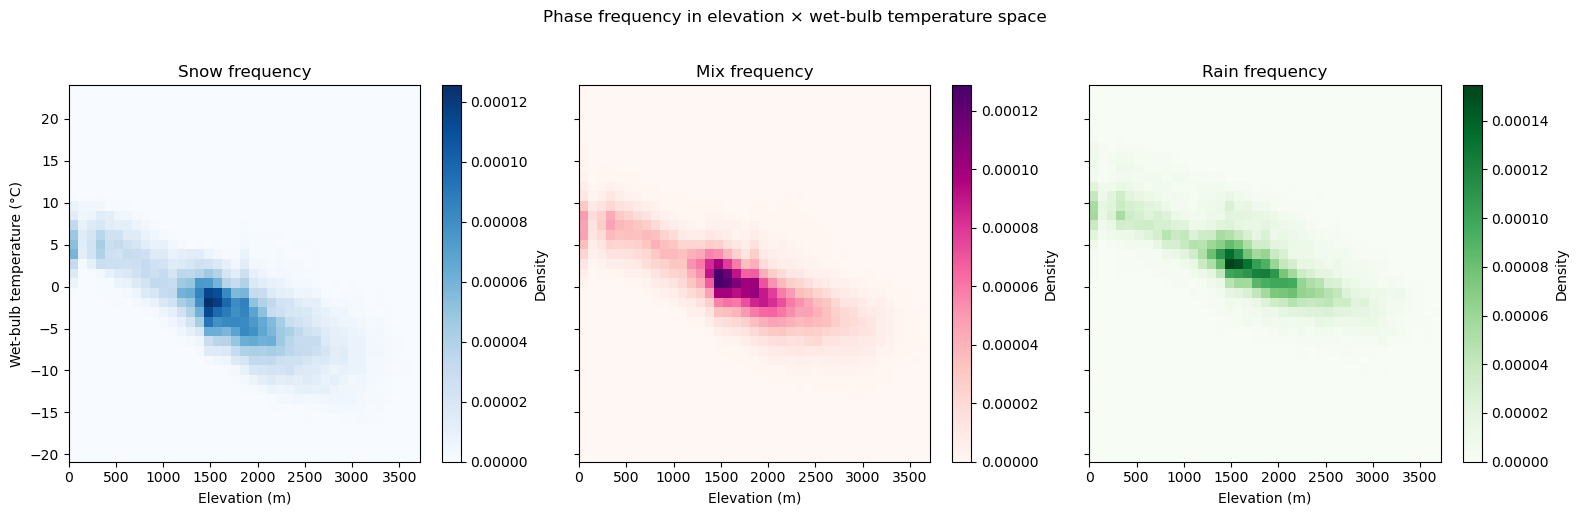

In [11]:
# -------------------------------------------------------------------
# C. Elevation × wet-bulb temperature phase frequency
# -------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

# Bin definitions
elev_bins = np.linspace(df_visualize["elev"].min(), df_visualize["elev"].max(), 40)
tw_bins   = np.linspace(df_visualize["temp_wet"].min(), df_visualize["temp_wet"].max(), 40)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)

phase_labels = {0: "Snow", 1: "Mix", 2: "Rain"}
phase_colors = {0: "Blues", 1: "RdPu", 2: "Greens"}

for ax, ph in zip(axes, [0, 1, 2]):
    sub = df_visualize[df_visualize["phase"] == ph]
    h, xedges, yedges = np.histogram2d(
        sub["elev"],
        sub["temp_wet"],
        bins=[elev_bins, tw_bins],
        density=True,
    )

    im = ax.pcolormesh(
        xedges,
        yedges,
        h.T,
        cmap=phase_colors[ph],
        shading="auto",
    )

    ax.set_title(f"{phase_labels[ph]} frequency")
    ax.set_xlabel("Elevation (m)")
    if ax is axes[0]:
        ax.set_ylabel("Wet-bulb temperature (°C)")

    plt.colorbar(im, ax=ax, label="Density")

fig.suptitle("Phase frequency in elevation × wet-bulb temperature space", y=1.02)
plt.tight_layout()
plt.show()


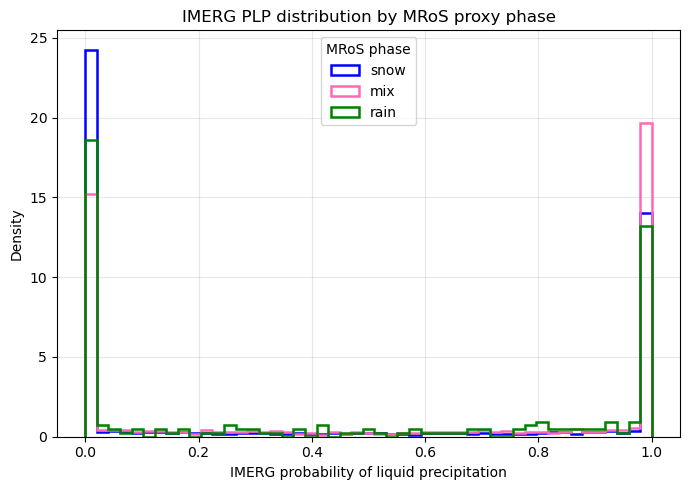

In [12]:
# -------------------------------------------------------------------
# D. IMERG PLP vs MRoS phase distribution
# -------------------------------------------------------------------

plt.figure(figsize=(7, 5))

for ph, name in phase_name_map.items():
    sub = df_visualize[df_visualize["phase"] == ph]

    plt.hist(
        sub["imerg_plp"],
        bins=np.linspace(0, 1, 50),
        density=True,
        histtype="step",
        linewidth=1.8,
        label=name,
        color=colors[name],
    )

plt.xlabel("IMERG probability of liquid precipitation")
plt.ylabel("Density")
plt.title("IMERG PLP distribution by MRoS proxy phase")
plt.legend(title="MRoS phase")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


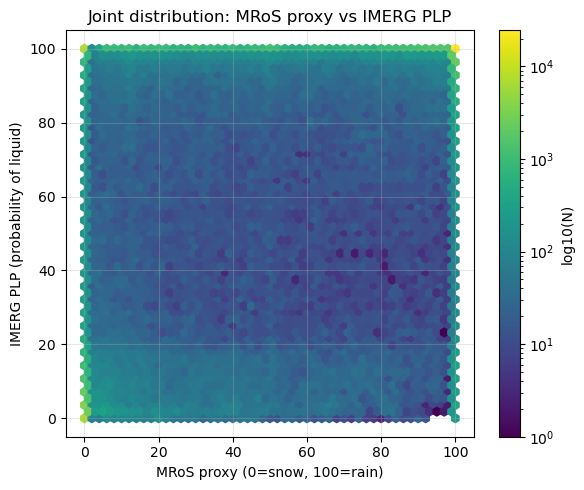

In [21]:
# -------------------------------------------------------------------
# MRoS proxy vs IMERG PLP: joint distribution
# -------------------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6, 5))

plt.hexbin(
    df_visualize["mros_plp_proxy"],
    df_visualize["imerg_plp"],
    gridsize=50,
    bins="log",
)

plt.xlabel("MRoS proxy (0=snow, 100=rain)")
plt.ylabel("IMERG PLP (probability of liquid)")
plt.title("Joint distribution: MRoS proxy vs IMERG PLP")
cb = plt.colorbar()
cb.set_label("log10(N)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# -------------------------------------------------------------------
# Violin plots: predictor distributions by elevation band (pre-ML)
# -------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# To be safe, rebuild a clean subset for visualization only:
predictors = [
    "temp_air",
    "temp_dew",
    "temp_wet",
    "rh",
    "imerg_plp",
    "prism_tair",
    "prism_tmean",
    "prism_tdmean",
]

cols_for_viz = ["elev"] + predictors

df_visualize = df_visualize[cols_for_viz].copy()

# IMPORTANT: drop the MultiIndex completely, do NOT turn it into columns
df_visualize = df_visualize.reset_index(drop=True)

# Define elevation bands (adjust breaks if you want different bins)
elev_bins = [0, 1500, 2000, 2500, 3000, np.inf]
elev_labels = ["<1500", "1500–2000", "2000–2500", "2500–3000", ">3000"]

df_visualize["elev_band"] = pd.cut(
    df_visualize["elev"],
    bins=elev_bins,
    labels=elev_labels,
    include_lowest=True,
)

n_vars = len(predictors)
n_cols = 3
n_rows = int(np.ceil(n_vars / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    sharex=False,
)
axes = axes.ravel()

for ax, var in zip(axes, predictors):
    sub = df_visualize[["elev_band", var]].dropna()
    if sub.empty:
        ax.set_visible(False)
        continue

    sns.violinplot(
        data=sub,
        x="elev_band",
        y=var,
        ax=ax,
        inner="quartile",
        cut=0,
        linewidth=1,
    )

    ax.set_title(var)
    ax.set_xlabel("Elevation band (m)")
    ax.set_ylabel(var)
    ax.grid(alpha=0.3)

# Hide any unused axes
for ax in axes[n_vars:]:
    ax.set_visible(False)

fig.suptitle("Predictor distributions by elevation band (pre-ML)", y=0.92)
plt.tight_layout()
plt.show()


## Step 2: Labeling and confidence masking

In [20]:
# Define phase thresholds

# def classify_phase(proxy):
#     return xr.where(
#         proxy >= 0.75, 2,          # rain
#         xr.where(proxy <= 0.25, 0,  # snow
#                  1)                # mix
#     )

# TODO: double check this breakdown...
phase = xr.where(
    ds_interp["mros_plp_proxy"] == 100, 2,
    xr.where(ds_interp["mros_plp_proxy"] == 0, 0, 1)
)

# Create mask to enfornce valid samples... 
# Not all gridcell hours are reliable from MRoS proxy (it's not actually ground truth, some estimates may be low confidence) 
# or IMERG (many hours are non-precipitating).
label_mask = (
    ds_interp["mros_plp_proxy"].notnull() &
    (ds_imerg["imerg_plp"] > 0.05)
)

labels = xr.Dataset(
    {
        "phase": phase,
        "label_mask": label_mask,
    },
    coords=predictors.coords
)

if interp_type == "IDW":
    out_labels = SETUP_DIR / "labels_phase_hourly_1km_withIDW.nc"
elif interp_type == "kriging":
    out_labels = SETUP_DIR / "labels_phase_hourly_1km_withKriging.nc"
else:
    raise ValueError(f"Unknown interp_type: {interp_type}")

labels.to_netcdf(
    out_labels,
    encoding={"phase": {"zlib": True}, "label_mask": {"zlib": True}}
)


## Step 3: Gridded to tabular extraction + spatial blocking

In [21]:
# Parquets will be much faster to use in ML... convert aligned gridded predictors + labels into a single, analysis-ready tabular dataset, apply label masking, assign spatial blocks, and write to Parquet once.

# SETUP_DIR = DATA_DIR / "compiled_input_predictors"
# predictors = xr.open_dataset(SETUP_DIR / "predictors_hourly_1km.nc")
# labels     = xr.open_dataset(SETUP_DIR / "labels_phase_hourly_1km.nc")

# Check label mask
label_mask = labels["label_mask"]

mask_frac = float(label_mask.mean())
print(f"Fraction of gridcell-hours kept: {mask_frac:.3f}")

Fraction of gridcell-hours kept: 0.131


Output mask_frac comes out to 0.131.. (13.1% is appropriate based on literature; reflects spatial sparsity of precip and intermittency of storms).

When multiplied by 184 million possible gridcell hours (5160 hrs x 251x142 cells ~= 184 mill) 
--> ~24 million samples (sufficient for ML).
Precip is rare in space and time, since most gridcells are dry most of the time, and even during storms precip is spatially patchy.
MRoS proxy is also sparse by design (crowd-sourced, opportunistic, spatially unevenm biased towards population centers), so we want to exclude unlabeled areas and low-confidence proxy estimates

In [22]:
# Reshaping/stacking to convert each (time, x, y) gridcell into one ML sample

predictors_stacked = predictors.stack(sample=("time", "y", "x"))
labels_stacked     = labels.stack(sample=("time", "y", "x"))
mask_stacked       = label_mask.stack(sample=("time", "y", "x"))

# Apply confidence mask after stacking to remove entire samples that fail label validity criteria. 
# This helps ensure that every retained sample has a usable phase label... a
# Aso reduces dataset size to enhance label quality.
predictors_valid = predictors_stacked.where(mask_stacked, drop=True)
labels_valid     = labels_stacked.where(mask_stacked, drop=True)


# At this point:
# - every remaining row has a valid phase label
# - no NaN label rows survive

# Up until this point, xarray was useful because it enforced coordinate alignment, supported label dimensions, etc... but ML libraries will require 2D tabular inputs.
# So, we convert to pandas:

# Convert to pandas
X = predictors_valid.to_dataframe()
y = labels_valid[["phase"]].to_dataframe()[["phase"]] # phase target is kept separately to prevent leakage

# Identify index names (these will be inserted by reset_index) and enforce uniqueness prior to flattening
index_cols = X.index.names  # typically ['time', 'y', 'x']

# Master dataframe of reshaped gridcell-time samples with mask applied; contains predictor columns
master_df = (
    X.drop(columns=index_cols, errors="ignore")
     .join(y, how="inner")
     .reset_index()
)

print(master_df.columns)

assert master_df.columns.duplicated().sum() == 0

# Now each row is a single gridcell at a single hour.
# Predictor columns
# Target phase column
# Spatiotemporal metadata columns (x, y, time)

# OUT_DIR = DATA_DIR / "parquet"
# OUT_DIR.mkdir(exist_ok=True)

# OUT_PATH = OUT_DIR / "ml_table_hourly_1km.parquet"

# master_df.to_parquet(
#     OUT_PATH,
#     engine="pyarrow",
#     compression="snappy",
#     index=False,
# )

Index(['time', 'y', 'x', 'temp_air', 'temp_dew', 'temp_wet', 'rh', 'imerg_plp',
       'prism_tair', 'prism_tmean', 'prism_tdmean', 'prism_ppt_daily', 'elev',
       'phase'],
      dtype='object')


In [23]:
# Check class balance (by phase)
master_df["phase"].value_counts(normalize=True)

phase
1.0    0.546022
0.0    0.232142
2.0    0.221836
Name: proportion, dtype: float64

In [24]:
# Temporal coverage (by month)
master_df.groupby(master_df["time"].dt.month)["phase"].count()

time
1     1868147
2     5409812
3     3545118
4     2070457
5     1211828
10     819766
11    4602029
12    4477986
Name: phase, dtype: int64

In [25]:
# Spatial coverage
master_df.groupby(["x", "y"]).size().describe()

count    35642.000000
mean       673.507183
std         24.044595
min        504.000000
25%        672.000000
50%        682.000000
75%        688.000000
max        688.000000
dtype: float64

## Step 4: Spatial Blocking
### 4a: Defining spatial blocks
Motivation: Standard random cross-validation grossly overestimates ML skill when data are spatially autocorrelated.
Guiding literature: Stock & Subramaniam (2022); https://doi.org/10.1080/15481603.2022.2107113
- Random splits allow near-duplicate information to leak across train/test
- Reported accuracy becomes meaningless for true spatial generalization

In our case, neighboring gridcells share:
- elevation
- meteorology
- storm structure
Random CV would dramatically overestimate phase-prediction skill

In [26]:
# Each row = one labeled gridcell-hour
# predictors:
    # temp_air, temp_dew, temp_wet, rh,
    # imerg_plp,
    # prism_tair, prism_tmean, prism_tdmean, prism_ppt_daily,
    # elev
# target: phase (0 snow / 1 mix / 2 rain)
# metadata: time, x, y, block_id

BLOCK_SIZE_M = 25_000

master_df["block_x"] = (master_df["x"] // BLOCK_SIZE_M).astype(np.int32)
master_df["block_y"] = (master_df["y"] // BLOCK_SIZE_M).astype(np.int32)

master_df["block_id"] = list(zip(master_df["block_x"], master_df["block_y"]))

print(master_df["block_id"].nunique(), "unique spatial blocks")

master_df["block_id"].value_counts().describe()



77 unique spatial blocks


count        77.000000
mean     311755.103896
std      158773.122519
min        2736.000000
25%      223212.000000
50%      419110.000000
75%      427027.000000
max      430000.000000
Name: count, dtype: float64

In [27]:
# Drop tiny blocks
block_counts = master_df["block_id"].value_counts()

keep_blocks = block_counts[block_counts >= 25_000].index
master_df = master_df[master_df["block_id"].isin(keep_blocks)].copy()

print("Blocks kept:", master_df["block_id"].nunique())
master_df["block_id"].value_counts().describe()


Blocks kept: 70


count        70.000000
mean     341556.514286
std      133613.411836
min       54306.000000
25%      223600.000000
50%      420858.000000
75%      427445.000000
max      430000.000000
Name: count, dtype: float64

### 4b: Random Block Splitting

Starting with single-partition spatial holdout validation (random block split). 
Can try full iterative spatial leave-one-out-cross-validation (SLOO-CV) later.

In [28]:
# Extract unique blocks and shufflt
# 
rng = np.random.default_rng(42)

blocks = master_df["block_id"].unique()
rng.shuffle(blocks)

n_blocks = len(blocks)
print("Total blocks:", n_blocks)


Total blocks: 70


In [29]:
# Define split sizes (70 / 15/ 15)
n_train = int(0.70 * n_blocks)
n_val   = int(0.15 * n_blocks)

train_blocks = set(blocks[:n_train])
val_blocks   = set(blocks[n_train:n_train + n_val])
test_blocks  = set(blocks[n_train + n_val:])

assert train_blocks.isdisjoint(val_blocks)
assert train_blocks.isdisjoint(test_blocks)
assert val_blocks.isdisjoint(test_blocks)

print(len(train_blocks), len(val_blocks), len(test_blocks))

49 10 11


In [30]:
# Assign split labels to rows

def assign_split(bid):
    if bid in train_blocks:
        return "train"
    elif bid in val_blocks:
        return "val"
    else:
        return "test"

# This master_df master table is now the bridge between ML space and geophysical space.
master_df["split"] = master_df["block_id"].map(assign_split)

assert master_df["split"].notna().all()
print(master_df["split"].value_counts(normalize=True))

split
train    0.692157
test     0.163938
val      0.143905
Name: proportion, dtype: float64


In [31]:
# Class balance diagnostics
phase_map = {0: "snow", 1: "mix", 2: "rain"}

overall = (
    master_df["phase"]
    .value_counts(normalize=True)
    .rename(index=phase_map)
)

print("Overall class balance:")
print(overall)


Overall class balance:
phase
mix     0.545899
snow    0.232243
rain    0.221858
Name: proportion, dtype: float64


In [32]:
by_split = (
    master_df.groupby("split")["phase"]
      .value_counts(normalize=True)
      .rename(index=phase_map)
      .unstack()
)

print("Class balance by split:")
print(by_split)

Class balance by split:
phase       mix      rain      snow
split                              
test   0.570433  0.208784  0.220783
train  0.544959  0.221064  0.233977
val    0.522473  0.240569  0.236958


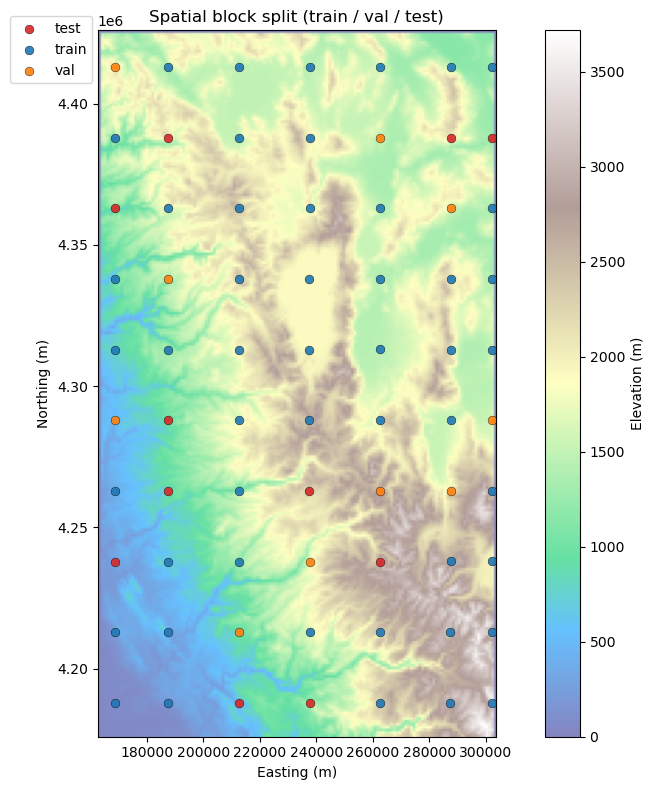

split
test      3919579
train    16548760
val       3440617
Name: n_samples, dtype: int64

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# Select DEM
dem = ds_interp["elev"]  # our DEM exists in any of the interpolated datasets

# Handle nodata if present
dem_vals = dem.values
if "_FillValue" in dem.attrs:
    dem_vals = np.where(dem_vals == dem.attrs["_FillValue"], np.nan, dem_vals)

# Compute spatial extent from coords
extent = [
    float(dem["x"].min()),
    float(dem["x"].max()),
    float(dem["y"].min()),
    float(dem["y"].max())
]

# Decide origin based on y direction
if float(dem["y"][0]) > float(dem["y"][-1]):
    # y decreases from north to south → put row 0 at the top (max y)
    origin = "upper"
else:
    origin = "lower"

# Spatial diagnostics
block_df = (
    master_df.groupby("block_id")
      .agg(
          x_mean=("x", "mean"),
          y_mean=("y", "mean"),
          split=("split", "first"),
          n=("phase", "size")
      )
      .reset_index()
)

colors = {"train": "tab:blue", "val": "tab:orange", "test": "tab:red"}

fig, ax = plt.subplots(figsize=(10, 8))

# 1) DEM underlay
im = ax.imshow(
    dem_vals,
    extent=extent,
    origin=origin,
    cmap="terrain",
    alpha=0.6
)

# 2) Block centroids
for split, g in block_df.groupby("split"):
    ax.scatter(
        g["x_mean"], g["y_mean"],
        s=40,
        c=colors[split],
        label=split,
        alpha=0.9,
        edgecolor="k",
        linewidths=0.3
    )

ax.legend(
    loc="upper left",
    bbox_to_anchor=(-0.22, 1.02),  # left of axes, slightly above
    frameon=True,
    borderaxespad=0.0
)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_title("Spatial block split (train / val / test)")
ax.set_aspect("equal")

cbar = fig.colorbar(im, ax=ax, label="Elevation (m)")
fig.tight_layout()
fig.savefig(GRAPHICS_DIR / f"spatial_block_split_{interp_type}.png", dpi=200, bbox_inches="tight")
plt.show()

master_df.groupby("split").size().rename("n_samples")


## Step 5: XGBoost Model Architecture

In [36]:
FEATURES = [
    "temp_air", "temp_dew", "temp_wet", "rh",
    "imerg_plp",
    "prism_tair", "prism_tmean", "prism_tdmean", "prism_ppt_daily",
    "elev",
]

TARGET = "phase"

# Prepare set matrices: 
# Recall: rows correspond to one space-time sample (i.e., one gridcell x one hour), 
# but the specific time/x/y details are now dropped intentionally (they still exist in "master_df")
X_train = master_df.loc[master_df["split"] == "train", FEATURES]
y_train = master_df.loc[master_df["split"] == "train", TARGET]

X_val   = master_df.loc[master_df["split"] == "val", FEATURES]
y_val   = master_df.loc[master_df["split"] == "val", TARGET]

X_test  = master_df.loc[master_df["split"] == "test", FEATURES]
y_test  = master_df.loc[master_df["split"] == "test", TARGET]


In [37]:
# Handle class imbalance... compute class weights from training set
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0,1,2])
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train.values
)

class_weight = dict(zip(classes, weights))
print("Class weights:", class_weight)

sample_weight_train = y_train.map(class_weight).values
sample_weight_val   = y_val.map(class_weight).values

Class weights: {np.int64(0): np.float64(1.4246411658311875), np.int64(1): np.float64(0.6116672648888103), np.int64(2): np.float64(1.5078565211207302)}


### Train!

In [38]:
# Train with XGboost (~120 mins to run for IDW)

import xgboost as xgb

params = {
    "objective": "multi:softprob",
    "num_class": 3,
    "eval_metric": "mlogloss",
    "max_depth": 6,
    "eta": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 5,
    "lambda": 1.0,
    "tree_method": "hist",
    "seed": 42,
}


dtrain = xgb.DMatrix(X_train, label=y_train, weight=sample_weight_train)
dval   = xgb.DMatrix(X_val,   label=y_val,   weight=sample_weight_val)
dtest  = xgb.DMatrix(X_test,  label=y_test)

# What to look for:
# - Early stopping should trigger well before 2000 trees
# - Validation loss should decrease smoothly
# - If it oscillates wildly → reduce depth or learning rate

evals = [(dtrain, "train"), (dval, "val")]
evals_result = {}

booster = xgb.train(
    params,
    dtrain,
    num_boost_round=2000,
    evals=evals,
    evals_result=evals_result,
    early_stopping_rounds=50,
    verbose_eval=50,
)

# Extract loss curves from evals_result
train_loss = evals_result["train"]["mlogloss"]
val_loss   = evals_result["val"]["mlogloss"]

n_iters = len(train_loss)
iters = np.arange(n_iters)

df_training = pd.DataFrame({
    "iter": iters,
    "train_mlogloss": train_loss,
    "val_mlogloss": val_loss,
})

# Save
logloss_path = MODEL_OUT_DIR / f"xgb_mlogloss_{interp_type}.csv"
df_training.to_csv(logloss_path, index=False)
print("Saved training logloss history to:", logloss_path)


# Predict: test outputs
y_test_prob = booster.predict(dtest)  # shape (n_samples, 3); probabilities for snow/mix/rain
y_test_pred = y_test_prob.argmax(axis=1) # shape (n_samples); hard class predictions


[0]	train-mlogloss:1.08951	val-mlogloss:1.08919
[50]	train-mlogloss:0.93235	val-mlogloss:0.94308
[100]	train-mlogloss:0.89720	val-mlogloss:0.91400
[150]	train-mlogloss:0.87884	val-mlogloss:0.90028
[200]	train-mlogloss:0.86523	val-mlogloss:0.89073
[250]	train-mlogloss:0.85412	val-mlogloss:0.88284
[300]	train-mlogloss:0.84375	val-mlogloss:0.87543
[350]	train-mlogloss:0.83436	val-mlogloss:0.86889
[400]	train-mlogloss:0.82537	val-mlogloss:0.86259
[450]	train-mlogloss:0.81724	val-mlogloss:0.85710
[500]	train-mlogloss:0.80966	val-mlogloss:0.85211
[550]	train-mlogloss:0.80203	val-mlogloss:0.84679
[600]	train-mlogloss:0.79508	val-mlogloss:0.84200
[650]	train-mlogloss:0.78845	val-mlogloss:0.83761
[700]	train-mlogloss:0.78240	val-mlogloss:0.83348
[750]	train-mlogloss:0.77668	val-mlogloss:0.82947
[800]	train-mlogloss:0.77096	val-mlogloss:0.82531
[850]	train-mlogloss:0.76503	val-mlogloss:0.82115
[900]	train-mlogloss:0.75975	val-mlogloss:0.81740
[950]	train-mlogloss:0.75530	val-mlogloss:0.81435
[10

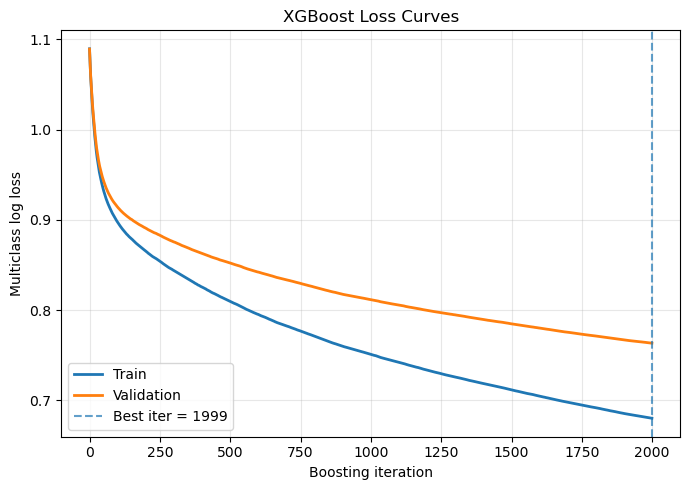

In [42]:
# Visualize loss curves

import matplotlib.pyplot as plt

train_loss = evals_result["train"]["mlogloss"]
val_loss   = evals_result["val"]["mlogloss"]

iters = np.arange(len(train_loss))

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(iters, train_loss, label="Train", lw=2)
ax.plot(iters, val_loss, label="Validation", lw=2)

# Best iteration (early stopping)
best_iter = booster.best_iteration
ax.axvline(best_iter, ls="--", lw=1.5, alpha=0.7,
           label=f"Best iter = {best_iter}")

ax.set_xlabel("Boosting iteration")
ax.set_ylabel("Multiclass log loss")
ax.set_title("XGBoost Loss Curves")
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(GRAPHICS_DIR / f"XGBoost_loss_curves.png", dpi=200, bbox_inches="tight")
plt.show()


### Diagnostics

In [43]:
# Core test set evaluation

from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_test_pred, labels=[0,1,2])
print(cm)

print(classification_report(
    y_test, y_test_pred,
    target_names=["snow","mix","rain"],
    digits=3
))

[[ 565172  210539   89666]
 [ 482681 1305693  447484]
 [  75648  173983  568713]]
              precision    recall  f1-score   support

        snow      0.503     0.653     0.568    865377
         mix      0.773     0.584     0.665   2235858
        rain      0.514     0.695     0.591    818344

    accuracy                          0.622   3919579
   macro avg      0.597     0.644     0.608   3919579
weighted avg      0.659     0.622     0.628   3919579



In [44]:
# Probabillistic performance: multi-class log loss

from sklearn.metrics import log_loss

print("Test log loss:", log_loss(y_test, y_test_prob))


Test log loss: 0.7790469939116822


In [45]:
# brier score by class

from sklearn.metrics import brier_score_loss

for i, name in enumerate(["snow","mix","rain"]):
    print(
        name,
        brier_score_loss((y_test == i).astype(int), y_test_prob[:, i])
    )


snow 0.1351499484614233
mix 0.2200075586069997
rain 0.12389676591845095


In [46]:
# Add predictions back to dataframe
# Here, df_test is composed of the original master_df (with time, x, y) and the predictions.

# df_test is the important output!

df_test = master_df.loc[master_df["split"] == "test"].copy()
df_test["p_snow"] = y_test_prob[:,0]
df_test["p_mix"]  = y_test_prob[:,1]
df_test["p_rain"] = y_test_prob[:,2]
df_test["pred"]   = y_test_pred

# Prediction confidence by class
df_test.groupby("phase")[["p_snow", "p_mix", "p_rain"]].mean()


,p_snow,p_mix,p_rain
phase,,,
0.0,0.523246,0.318375,0.158379
1.0,0.262468,0.498856,0.238676
2.0,0.155001,0.308926,0.536073


In [47]:
# Entropy
from scipy.stats import entropy

df_test["entropy"] = entropy(
    y_test_prob.T, base=2
)

df_test.groupby("phase")["entropy"].describe()

# High entropy → uncertain phase (often near 0 °C, complex storms)
# Low entropy → confident snow or rain

,count,mean,std,min,25%,50%,75%,max
phase,,,,,,,,
0.0,865377.0,1.179210,0.298906,0.006909,1.010521,1.223521,1.419845,1.584962
1.0,2235858.0,1.180007,0.283604,0.004699,1.026970,1.210244,1.398727,1.584962
2.0,818344.0,1.158116,0.306400,0.008858,0.976612,1.200759,1.410311,1.584962


In [48]:
# Temporal check
df_test.groupby(df_test["time"].dt.date)["p_snow"].mean()

time
2024-10-16    0.003146
2024-10-17    0.005068
2024-10-18    0.396789
2024-10-28    0.199170
2024-10-29    0.344118
                ...   
2025-05-04    0.027843
2025-05-12    0.285626
2025-05-13    0.334771
2025-05-14    0.186372
2025-05-17    0.299683
Name: p_snow, Length: 86, dtype: float32

In [49]:
# Spatial check
df_test.groupby(["x", "y"])["pred"].value_counts(normalize=True)

x              y             pred
162630.918259  4.225926e+06  1       0.526163
                             0       0.236919
                             2       0.236919
               4.226926e+06  1       0.518895
                             2       0.242733
                                       ...   
303630.918259  4.398926e+06  2       0.276316
                             0       0.238304
               4.399926e+06  1       0.486842
                             2       0.276316
                             0       0.236842
Name: proportion, Length: 17250, dtype: float64

In [50]:
# Spatiotemporal check
df_test.groupby([df_test["time"].dt.month, "y"])["p_snow"].mean()

time  y           
1     4.175926e+06    0.439203
      4.176926e+06    0.440676
      4.177926e+06    0.442985
      4.178926e+06    0.449565
      4.179926e+06    0.455764
                        ...   
12    4.395926e+06    0.252347
      4.396926e+06    0.250823
      4.397926e+06    0.249105
      4.398926e+06    0.248385
      4.399926e+06    0.249080
Name: p_snow, Length: 1200, dtype: float32

### Export trained model (Booster) along with feature matrix to be used for SHAP, metadata, and test predictions. 

In [51]:
# Save model
model_path = MODEL_OUT_DIR / "xgb_phase_model.bin"
booster.save_model(model_path)

# Booster contains:
# the full ensemble of trees
# split rules
# learned feature interactions
# class probability logic (multi:softprob)

C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_25028\288922645.py:3: UserWarning: [15:05:40] WARNING: D:\bld\xgboost-split_1765326876395\work\src\c_api\c_api.cc:1575: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  booster.save_model(model_path)


In [52]:
# Save feature matrices
import json

feature_names = list(X_train.columns)

with open(MODEL_OUT_DIR / "feature_names.json", "w") as f:
    json.dump(feature_names, f, indent=2)

In [53]:
# Save representative feature data

X_test.to_parquet(MODEL_OUT_DIR / "X_test.parquet")

# Also test labels + predictions
df_test_out = df_test[
    ["time", "x", "y", "phase", "pred", "p_snow", "p_mix", "p_rain", "block_id"]
]

df_test_out.to_parquet(MODEL_OUT_DIR / "test_predictions.parquet")

# Also just save the entire test output dataframe
df_test.to_parquet(MODEL_OUT_DIR / "X_test_predictions_combined.parquet")

In [54]:
metadata = {
    "classes": {
        "0": "snow",
        "1": "mix",
        "2": "rain"
    },
    "model_type": "XGBoost (multi:softprob)",
    "spatial_blocking": "random block split, ~25–50 km blocks",
    "training_period": "2024-10-11 to 2025-05-30",
    "label_source": "MRoS proxy, IMERG PLP mask",
    "notes": "Model trained with spatial blocking and early stopping on IDW set"
}

with open(MODEL_OUT_DIR / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)


### Sample code to pick up from saved outputs:

In [ ]:
# import xgboost as xgb
# import shap
# import pandas as pd
# import json

# # Load model
# booster = xgb.Booster()
# booster.load_model("xgb_phase_model.bin")

# # Load features
# X_shap = pd.read_parquet("X_test.parquet")

# # Load feature names
# with open("feature_names.json") as f:
#     feature_names = json.load(f)

# X_shap = X_shap[feature_names]  # enforce order

# # SHAP
# explainer = shap.TreeExplainer(booster)
# shap_values = explainer.shap_values(X_shap)


                        time              x             y  phase  pred  \
3705     2024-10-16 16:00:00  175630.918259  4.399926e+06    2.0     2   
3706     2024-10-16 16:00:00  176630.918259  4.399926e+06    2.0     2   
3707     2024-10-16 16:00:00  177630.918259  4.399926e+06    2.0     2   
3708     2024-10-16 16:00:00  178630.918259  4.399926e+06    2.0     2   
3709     2024-10-16 16:00:00  179630.918259  4.399926e+06    2.0     2   
...                      ...            ...           ...    ...   ...   
24040280 2025-05-17 22:00:00  245630.918259  4.175926e+06    1.0     1   
24040281 2025-05-17 22:00:00  246630.918259  4.175926e+06    1.0     1   
24040282 2025-05-17 22:00:00  247630.918259  4.175926e+06    1.0     1   
24040283 2025-05-17 22:00:00  248630.918259  4.175926e+06    1.0     1   
24040284 2025-05-17 22:00:00  249630.918259  4.175926e+06    1.0     1   

            p_snow     p_mix    p_rain  
3705      0.000153  0.010483  0.989365  
3706      0.000185  0.008776 